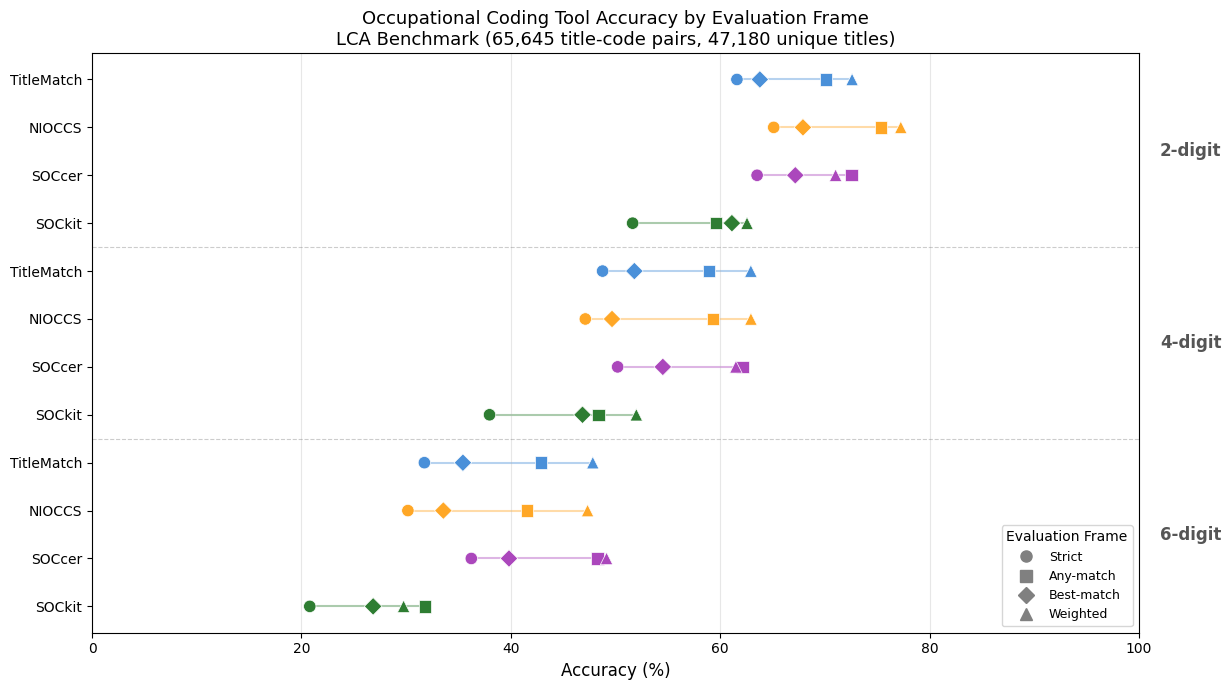

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# Construct the raw GitHub URL for the CSV file
csv_url = "https://raw.githubusercontent.com/pnorlander/JAAT_Demos/main/titlematch_validation/data/all_tools_comparison.csv"
df = pd.read_csv(csv_url, low_memory=False)

TOOLS = {'TitleMatch': 'tm', 'SOCkit': 'sockit', 'NIOCCS': 'nioccs', 'SOCcer': 'soccer'}
TOOL_COLORS = {'TitleMatch': '#4A90D9', 'SOCkit': '#2E7D32', 'NIOCCS': '#FFA726', 'SOCcer': '#AB47BC'}

def compute_rate(valid_df, tool_prefix, frame, n):
    col = f'{tool_prefix}_match_{n}_digit'
    if frame == 'Strict':
        return valid_df[col].astype(float).mean() * 100
    elif frame == 'Any-match':
        return valid_df[f'{tool_prefix}_any_match_{n}_digit'].astype(float).mean() * 100
    elif frame == 'Best-match':
        return valid_df[f'{tool_prefix}_best_match_{n}_digit'].astype(float).mean() * 100
    elif frame == 'Weighted':
        return (valid_df[col].astype(float) * valid_df['count']).sum() / valid_df['count'].sum() * 100

FRAMES = ['Strict', 'Any-match', 'Best-match', 'Weighted']
FRAME_MARKERS = {'Strict': 'o', 'Any-match': 's', 'Best-match': 'D', 'Weighted': '^'}

results = {}
active_tools = []
for tool_label, tool_prefix in TOOLS.items():
    col_check = f'{tool_prefix}_match_6_digit'
    if col_check not in df.columns or df[col_check].isna().all():
        continue
    active_tools.append(tool_label)
    valid = df[df[col_check].notna()]
    for frame in FRAMES:
        for n in [2, 4, 6]:
            results[(tool_label, frame, n)] = compute_rate(valid, tool_prefix, frame, n)

# Fixed display order
tool_order = ['TitleMatch', 'NIOCCS', 'SOCcer', 'SOCkit']
tool_order = [t for t in tool_order if t in active_tools]

y_labels = []
y_colors = []
y_data = []
for n in [2, 4, 6]:
    for tool in tool_order:
        y_labels.append(tool)
        y_colors.append(TOOL_COLORS[tool])
        y_data.append((tool, n))

fig, ax = plt.subplots(figsize=(13, max(7, len(y_labels) * 0.42)))
y_positions = list(range(len(y_labels) - 1, -1, -1))

for frame, marker in FRAME_MARKERS.items():
    x_vals = [results.get((tool, frame, n), np.nan) for tool, n in y_data]
    ax.scatter(x_vals, y_positions, marker=marker, s=80, zorder=3,
               color=y_colors, edgecolors='white', linewidth=0.5)

for i, (tool, n) in enumerate(y_data):
    vals = [results.get((tool, f, n), np.nan) for f in FRAMES]
    vals = [v for v in vals if not np.isnan(v)]
    if vals:
        ax.plot([min(vals), max(vals)], [y_positions[i], y_positions[i]],
                color=y_colors[i], linewidth=1.5, alpha=0.4, zorder=1)

# Section labels and separators
n_per_group = len(tool_order)
for group_idx, n in enumerate([2, 4, 6]):
    group_start = group_idx * n_per_group
    group_top = y_positions[group_start]
    group_bottom = y_positions[group_start + n_per_group - 1]
    group_mid = (group_top + group_bottom) / 2
    # Label on far right, outside plot area
    ax.annotate(f'{n}-digit', xy=(1.02, group_mid), xycoords=('axes fraction', 'data'),
                fontsize=12, fontweight='bold', color='#555555', va='center')
    if group_idx > 0:
        sep_y = (y_positions[group_start] + y_positions[group_start - 1]) / 2
        ax.axhline(y=sep_y, color='gray', linewidth=0.8, alpha=0.4, linestyle='--')

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=10)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)

legend_handles = [mlines.Line2D([], [], marker=m, color='gray', linestyle='None',
                                markersize=8, label=f) for f, m in FRAME_MARKERS.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9, title='Evaluation Frame')

ax.set_title('Occupational Coding Tool Accuracy by Evaluation Frame\n'
             f'LCA Benchmark ({len(df):,} title-code pairs, {df["job_title"].nunique():,} unique titles)',
             fontsize=13)
plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.show()

In [7]:
for n in [2, 4, 6]:
    rows = []
    for tool_label in active_tools:
        tool_prefix = TOOLS[tool_label]
        valid = df[df[f'{tool_prefix}_match_{n}_digit'].notna()]
        row = {
            'Tool': tool_label,
            'N': f'{len(valid):,}',
            'Strict': f'{compute_rate(valid, tool_prefix, "Strict", n):.1f}%',
            'Any-match': f'{compute_rate(valid, tool_prefix, "Any-match", n):.1f}%',
            'Best-match': f'{compute_rate(valid, tool_prefix, "Best-match", n):.1f}%',
            'Weighted': f'{compute_rate(valid, tool_prefix, "Weighted", n):.1f}%',
        }
        rows.append(row)
    print(f'=== {n}-Digit SOC ===')
    print(pd.DataFrame(rows).to_string(index=False))
    print()

=== 2-Digit SOC ===
      Tool      N Strict Any-match Best-match Weighted
TitleMatch 65,645  61.6%     70.1%      63.8%    72.6%
    SOCkit 65,645  51.6%     59.6%      61.1%    62.6%
    NIOCCS 57,640  65.1%     75.4%      67.9%    77.2%
    SOCcer 65,645  63.5%     72.5%      67.2%    71.0%

=== 4-Digit SOC ===
      Tool      N Strict Any-match Best-match Weighted
TitleMatch 65,645  48.8%     58.9%      51.8%    62.9%
    SOCkit 65,645  38.0%     48.4%      46.8%    52.0%
    NIOCCS 57,640  47.1%     59.3%      49.7%    62.9%
    SOCcer 65,645  50.2%     62.1%      54.5%    61.5%

=== 6-Digit SOC ===
      Tool      N Strict Any-match Best-match Weighted
TitleMatch 65,645  31.7%     42.9%      35.4%    47.8%
    SOCkit 65,645  20.8%     31.8%      26.8%    29.8%
    NIOCCS 57,640  30.2%     41.5%      33.6%    47.3%
    SOCcer 65,645  36.2%     48.3%      39.8%    49.1%



## Introduction

This notebook benchmarks four automated occupational coding tools against ground-truth Standard Occupational Classification (SOC) codes from the U.S. Department of Labor's Labor Condition Application (LCA) data.

**Why LCA data?** Employers filing LCAs must specify both a job title and a SOC code for each position. This produces a large-scale benchmark: 65,645 unique title-code pairs (47,180 unique titles) from 2008-2024.

**The problem:** Some job titles map to multiple SOC codes across filings — "Chief Operating Officer" appears under Chief Executives (11-1011), General and Operations Managers (11-1021), and others. For these titles, reported accuracy depends on how "correct" is defined.

**Tools compared:**
1. **TitleMatch** (JAAT) — semantic similarity via sentence embeddings, SOC 2018
2. **SOCkit** — classification model, SOC 2018
3. **NIOCCS** — NIOSH/CDC web API, SOC 2018
4. **SOCcer/SOCcerNET** — NCI neural network classifier, SOC 2010 (crosswalked to SOC 2018 via BLS crosswalk)

**Key findings:** (1) A tool's reported accuracy varies by 10-16 percentage points across evaluation frames. (2) Rankings shift by granularity — SOCcer leads at 6-digit after crosswalk correction, NIOCCS leads at 2-digit. (3) Weighting by filing frequency boosts TitleMatch and NIOCCS by 16-17pp, indicating strong performance on high-volume titles.

## Data

The analysis file merges ground-truth LCA codes with outputs from all four tools. Each row is a unique job title + SOC code pair, deduplicated across years — the `count` column sums all filings with that combination.

Titles are **uncleaned** — original capitalization, special characters, and formatting are preserved as they appear in LCA filings. This is intentional: it tests tool robustness to real-world input.

In [8]:
print(f'Rows: {len(df):,}')
print(f'Unique job titles: {df["job_title"].nunique():,}')
print(f'Year range: {df["year"].min()} - {df["year"].max()}')

print(f'\nVisa type distribution:')
visa_counts = df['visa'].value_counts()
for visa, n in visa_counts.items():
    print(f'  {visa:5s}: {n:>6,} ({n/len(df)*100:.1f}%)')

print(f'\nCount (weight) distribution:')
print(df['count'].describe().to_string())

print(f'\nTool coverage:')
for tool_label, tool_prefix in TOOLS.items():
    code_col = f'{tool_prefix}_code'
    if code_col in df.columns:
        n_coded = df[code_col].notna().sum()
        print(f'  {tool_label:12s}: {n_coded:>6,} / {len(df):,} ({n_coded/len(df)*100:.1f}%)')

Rows: 65,645
Unique job titles: 47,180
Year range: 2008 - 2024

Visa type distribution:
  h1b  : 53,735 (81.9%)
  perm :  8,804 (13.4%)
  h2a  :  1,824 (2.8%)
  cw   :    731 (1.1%)
  h2b  :    551 (0.8%)

Count (weight) distribution:
count    65645.000000
mean        43.694204
std        385.497761
min          5.000000
25%          8.000000
50%          9.000000
75%         20.000000
max      58589.000000

Tool coverage:
  TitleMatch  : 65,645 / 65,645 (100.0%)
  SOCkit      : 58,078 / 65,645 (88.5%)
  NIOCCS      : 61,296 / 65,645 (93.4%)
  SOCcer      : 65,645 / 65,645 (100.0%)


## The Ground Truth Problem

Most job titles in the LCA data (85%) map to a single SOC code — for these, there is an unambiguous ground truth. But the remaining 15% map to multiple codes, and these include many high-profile, high-volume titles. For ambiguous titles, what does it mean for a coding tool to be "correct"?

In [9]:
print('Distribution of SOC codes per job title:')
print(df['unique_occs_per_title'].describe().to_string())
print()

ambiguity = df.groupby('job_title')['unique_occs_per_title'].first()
print(f'Titles with exactly 1 SOC code: {(ambiguity == 1).sum():,} '
      f'({(ambiguity == 1).mean()*100:.1f}%)')
print(f'Titles with 2-5 SOC codes:      {((ambiguity >= 2) & (ambiguity <= 5)).sum():,} '
      f'({((ambiguity >= 2) & (ambiguity <= 5)).mean()*100:.1f}%)')
print(f'Titles with 6-20 SOC codes:     {((ambiguity >= 6) & (ambiguity <= 20)).sum():,} '
      f'({((ambiguity >= 6) & (ambiguity <= 20)).mean()*100:.1f}%)')
print(f'Titles with 21+ SOC codes:      {(ambiguity >= 21).sum():,} '
      f'({(ambiguity >= 21).mean()*100:.1f}%)')

Distribution of SOC codes per job title:
count    65645.000000
mean         4.010191
std          8.441918
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         78.000000

Titles with exactly 1 SOC code: 40,053 (84.9%)
Titles with 2-5 SOC codes:      6,308 (13.4%)
Titles with 6-20 SOC codes:     723 (1.5%)
Titles with 21+ SOC codes:      96 (0.2%)


In [10]:
case_title = 'CHIEF OPERATING OFFICER'
case = df[df['job_title'] == case_title].sort_values('count', ascending=False)
print(f'Case study: "{case_title}"')
print(f'  {len(case)} rows, {case["unique_occs_per_title"].iloc[0]} unique SOC codes\n')
print(case[['occupation_code', 'occ_labels', 'count', 'year']].head(10).to_string(index=False))

Case study: "CHIEF OPERATING OFFICER"
  7 rows, 7 unique SOC codes

 occupation_code                                occ_labels  count  year
          111011                          Chief Executives    389  2011
          111021           General and Operations Managers    338  2014
          113031                        Financial Managers     15  2013
          112021                        Marketing Managers      9  2019
          119199                       Managers, All Other      6  2011
          191029          Biological Scientists, All Other      6  2019
          113021 Computer and Information Systems Managers      5  2018


### Four evaluation frames

| Frame | Definition | Question |
|-------|-----------|----------|
| **Strict** | Tool code = this row's LCA code | Does the tool reproduce the specific employer-filed code? |
| **Any-match** | Tool code matches \*any\* LCA code for this title | Does the tool return a code that \*some\* employer used? |
| **Best-match** | Tool code = most common LCA code for this title | Does the tool agree with the modal employer choice? |
| **Weighted** | Strict match, weighted by filing count | How accurate is the tool on a typical LCA filing? |

In [11]:
tool = 'tm'
print('TitleMatch accuracy by evaluation frame:\n')
valid = df[df[f'{tool}_match_6_digit'].notna()]
for n in [2, 4, 6]:
    strict = compute_rate(valid, tool, 'Strict', n)
    any_m = compute_rate(valid, tool, 'Any-match', n)
    best_m = compute_rate(valid, tool, 'Best-match', n)
    weighted = compute_rate(valid, tool, 'Weighted', n)
    print(f'  {n}-digit:  Strict {strict:.1f}%  |  Any-match {any_m:.1f}%  |  '
          f'Best-match {best_m:.1f}%  |  Weighted {weighted:.1f}%')

# Theoretical ceiling: if a perfect tool always returned the modal code
modal = (df[df['lca_code'].notna()]
         .sort_values(['job_title', 'count', 'lca_code'], ascending=[True, False, True])
         .groupby('job_title')['lca_code'].first().to_dict())
df['_is_modal'] = df['lca_code'] == df['job_title'].map(modal)
ceil_unw = df['_is_modal'].mean() * 100
ceil_w = (df['_is_modal'].astype(float) * df['count']).sum() / df['count'].sum() * 100

print(f'\nTheoretical ceiling (oracle that always returns modal code):')
print(f'  Strict unweighted: {ceil_unw:.1f}%')
print(f'  Strict weighted:   {ceil_w:.1f}%')
print(f'\nThe gap between strict and any-match, and the distance from the '
      f'theoretical ceiling, both reflect ground truth ambiguity — not tool failure.')
df = df.drop(columns=['_is_modal'])

TitleMatch accuracy by evaluation frame:

  2-digit:  Strict 61.6%  |  Any-match 70.1%  |  Best-match 63.8%  |  Weighted 72.6%
  4-digit:  Strict 48.8%  |  Any-match 58.9%  |  Best-match 51.8%  |  Weighted 62.9%
  6-digit:  Strict 31.7%  |  Any-match 42.9%  |  Best-match 35.4%  |  Weighted 47.8%

Theoretical ceiling (oracle that always returns modal code):
  Strict unweighted: 69.2%
  Strict weighted:   71.1%

The gap between strict and any-match, and the distance from the theoretical ceiling, both reflect ground truth ambiguity — not tool failure.


## Tool Comparison: Headline Results

How do the four tools compare across all evaluation frames?

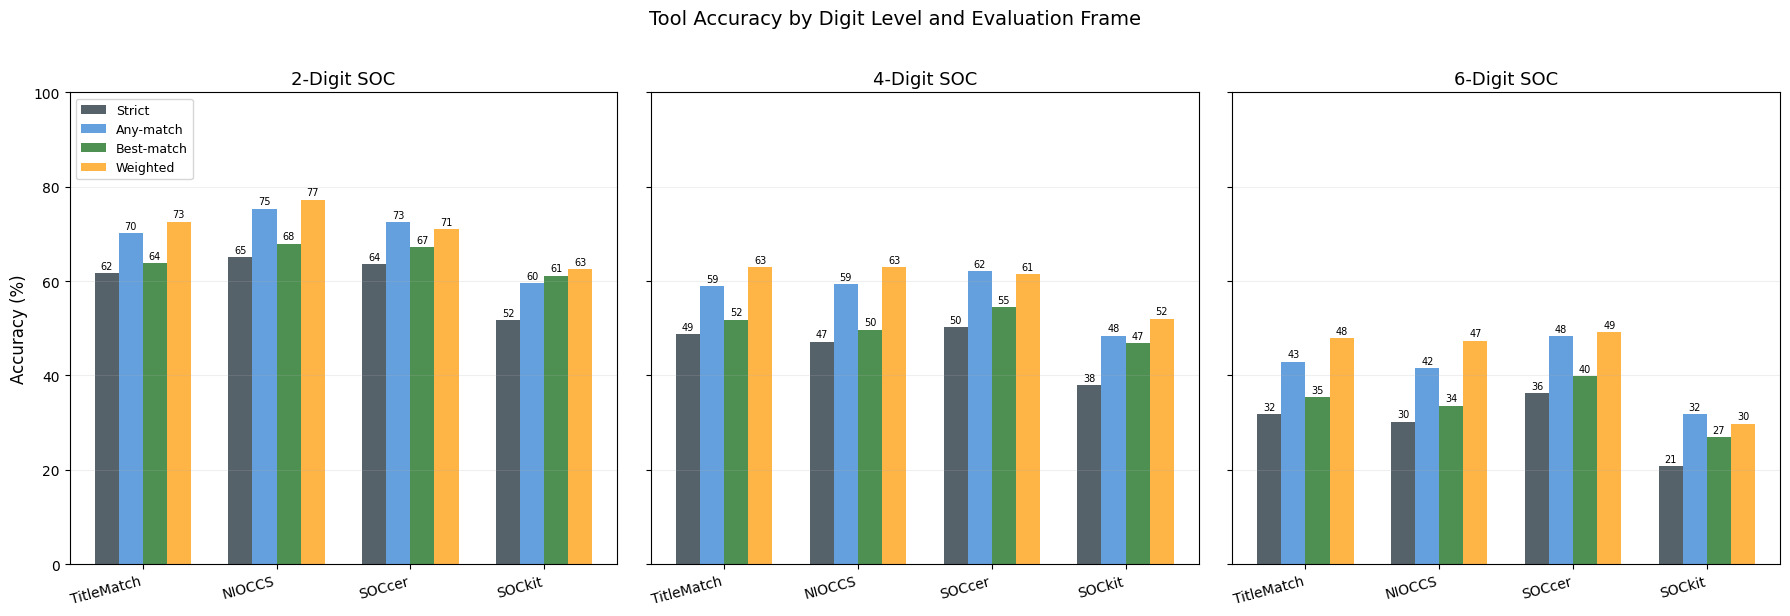

In [12]:
frame_names = FRAMES
frame_colors = ['#37474F', '#4A90D9', '#2E7D32', '#FFA726']

# Match order to Figure 1
bar_tool_order = ['TitleMatch', 'NIOCCS', 'SOCcer', 'SOCkit']
bar_tool_order = [t for t in bar_tool_order if t in active_tools]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for panel_idx, n in enumerate([2, 4, 6]):
    ax = axes[panel_idx]
    n_tools = len(bar_tool_order)
    x = np.arange(n_tools)
    width = 0.18

    for i, frame in enumerate(frame_names):
        vals = []
        for tool_label in bar_tool_order:
            tool_prefix = TOOLS[tool_label]
            valid = df[df[f'{tool_prefix}_match_{n}_digit'].notna()]
            vals.append(compute_rate(valid, tool_prefix, frame, n))
        offset = (i - len(frame_names)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=frame if panel_idx == 0 else '',
                       color=frame_colors[i], alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(bar_tool_order, fontsize=10, rotation=15, ha='right')
    ax.set_title(f'{n}-Digit SOC', fontsize=13)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.2)

axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].legend(fontsize=9, loc='upper left')

fig.suptitle('Tool Accuracy by Digit Level and Evaluation Frame', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
for n in [2, 4, 6]:
    rows = []
    for tool_label in active_tools:
        tool_prefix = TOOLS[tool_label]
        valid = df[df[f'{tool_prefix}_match_{n}_digit'].notna()]
        row = {
            'Tool': tool_label,
            'N': f'{len(valid):,}',
            'Strict': f'{compute_rate(valid, tool_prefix, "Strict", n):.1f}%',
            'Any-match': f'{compute_rate(valid, tool_prefix, "Any-match", n):.1f}%',
            'Best-match': f'{compute_rate(valid, tool_prefix, "Best-match", n):.1f}%',
            'Weighted': f'{compute_rate(valid, tool_prefix, "Weighted", n):.1f}%',
        }
        rows.append(row)
    print(f'=== {n}-Digit SOC ===')
    print(pd.DataFrame(rows).to_string(index=False))
    print()

=== 2-Digit SOC ===
      Tool      N Strict Any-match Best-match Weighted
TitleMatch 65,645  61.6%     70.1%      63.8%    72.6%
    SOCkit 65,645  51.6%     59.6%      61.1%    62.6%
    NIOCCS 57,640  65.1%     75.4%      67.9%    77.2%
    SOCcer 65,645  63.5%     72.5%      67.2%    71.0%

=== 4-Digit SOC ===
      Tool      N Strict Any-match Best-match Weighted
TitleMatch 65,645  48.8%     58.9%      51.8%    62.9%
    SOCkit 65,645  38.0%     48.4%      46.8%    52.0%
    NIOCCS 57,640  47.1%     59.3%      49.7%    62.9%
    SOCcer 65,645  50.2%     62.1%      54.5%    61.5%

=== 6-Digit SOC ===
      Tool      N Strict Any-match Best-match Weighted
TitleMatch 65,645  31.7%     42.9%      35.4%    47.8%
    SOCkit 65,645  20.8%     31.8%      26.8%    29.8%
    NIOCCS 57,640  30.2%     41.5%      33.6%    47.3%
    SOCcer 65,645  36.2%     48.3%      39.8%    49.1%



## Accuracy by Title Ambiguity

85% of titles map to a single SOC code — these are unambiguous. The remaining 15% map to 2 or more codes. How does tool accuracy vary with this ambiguity? And does the evaluation frame matter more for ambiguous titles?

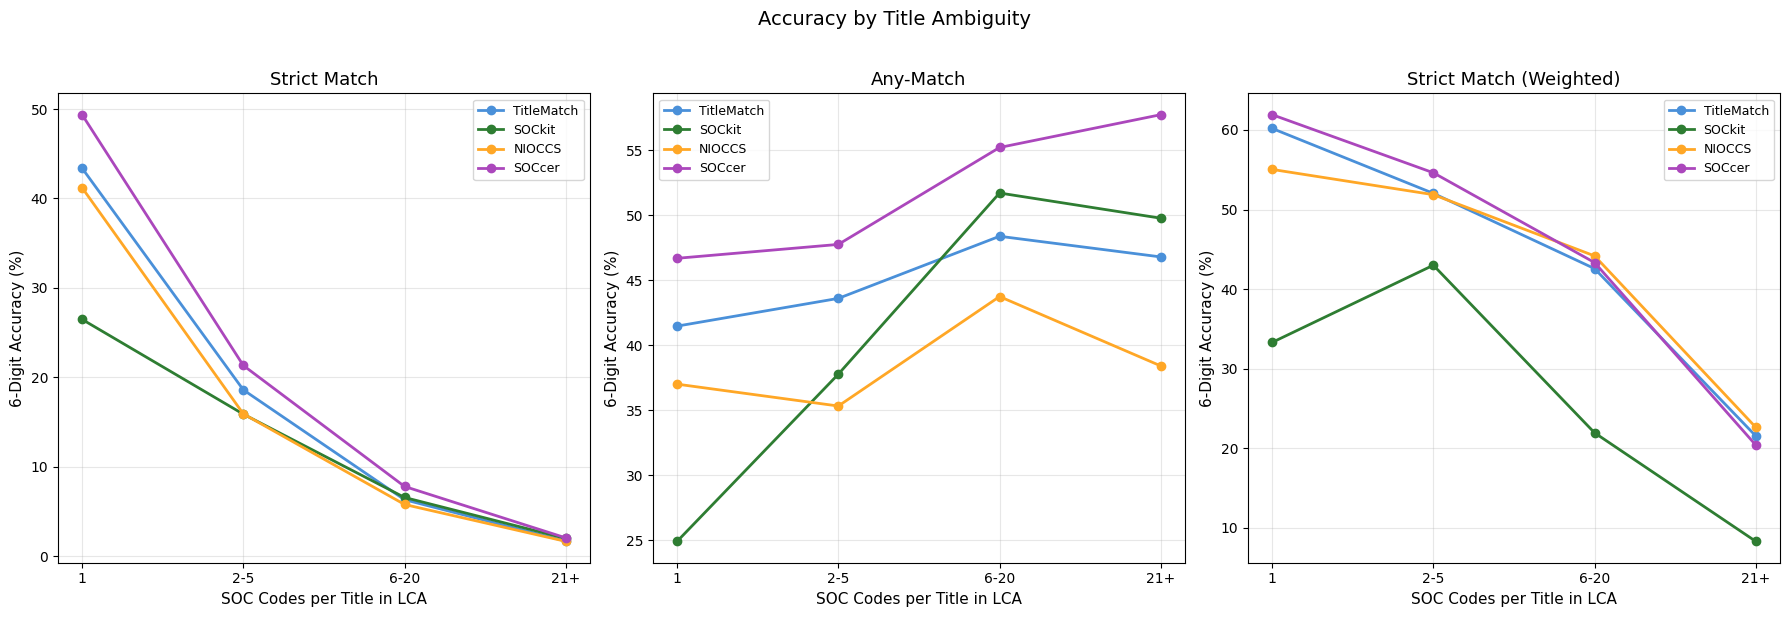

In [14]:
bins = [0, 1, 5, 20, 10000]
bin_labels = ['1', '2-5', '6-20', '21+']
df['ambiguity_bin'] = pd.cut(df['unique_occs_per_title'], bins=bins, labels=bin_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for panel_idx, (frame_suffix, frame_title) in enumerate([
    ('match', 'Strict Match'), ('any_match', 'Any-Match'), ('match', 'Strict Match (Weighted)')
]):
    ax = axes[panel_idx]
    for tool_label in active_tools:
        tool_prefix = TOOLS[tool_label]
        col = f'{tool_prefix}_{frame_suffix}_6_digit'
        if col not in df.columns or df[col].isna().all():
            continue

        if panel_idx == 2:
            # Weighted: compute weighted mean per bin
            valid = df[df[col].notna()].copy()
            valid['_match_float'] = valid[col].astype(float)
            valid['_weighted'] = valid['_match_float'] * valid['count']
            grouped = valid.groupby('ambiguity_bin', observed=True)
            rates = grouped['_weighted'].sum() / grouped['count'].sum() * 100
        else:
            rates = df.groupby('ambiguity_bin', observed=True)[col].mean() * 100

        ax.plot(rates.index, rates.values, marker='o', label=tool_label,
                color=TOOL_COLORS[tool_label], linewidth=2)

    ax.set_xlabel('SOC Codes per Title in LCA', fontsize=11)
    ax.set_ylabel('6-Digit Accuracy (%)', fontsize=11)
    ax.set_title(frame_title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Accuracy by Title Ambiguity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Under the strict frame, all tools degrade sharply on ambiguous titles — dropping from 27-44% accuracy on unambiguous titles to under 5% on highly ambiguous ones. This is partly an artifact of the ground truth: with many "correct" codes, any single tool output is less likely to match the specific code on a given row.

The any-match panel tells a different story. For ambiguous titles, accuracy *rises* — particularly for SOCkit and SOCcer — because with more attested codes, the tool is more likely to match at least one. TitleMatch maintains a consistent lead across ambiguity levels in the strict frame but converges with other tools under any-match.

Although only 15% of titles are ambiguous, these titles account for a disproportionate share of LCA filings (they tend to be common, generic titles like "Manager" or "Engineer"). Title ambiguity is a property of the labor market, not of the coding tools.

## Pairwise Tool Agreement

When tools disagree with the LCA ground truth, do they agree with *each other*? High pairwise agreement despite low LCA agreement suggests the tools are capturing something systematic that diverges from employer filing patterns.

In [15]:
tool_names = [t for t in active_tools if f'{TOOLS[t]}_code' in df.columns
              and df[f'{TOOLS[t]}_code'].notna().any()]

agreement_matrix = pd.DataFrame(index=tool_names, columns=tool_names, dtype=float)
for t1 in tool_names:
    for t2 in tool_names:
        c1 = f'{TOOLS[t1]}_code'
        c2 = f'{TOOLS[t2]}_code'
        valid = df[df[c1].notna() & df[c2].notna()]
        if len(valid) > 0:
            agreement_matrix.loc[t1, t2] = (valid[c1] == valid[c2]).mean() * 100

print('Pairwise 6-digit agreement (%):\n')
print(agreement_matrix.round(1).to_string())

Pairwise 6-digit agreement (%):

            TitleMatch  SOCkit  NIOCCS  SOCcer
TitleMatch       100.0    27.9    31.8    39.1
SOCkit            27.9   100.0    30.8    35.1
NIOCCS            31.8    30.8   100.0    39.8
SOCcer            39.1    35.1    39.8   100.0


## Weighted vs Unweighted

The `count` column indicates how many LCA filings had each title-code combination. Weighting by count answers: "How accurate is this tool on a randomly selected LCA filing?" — as opposed to "How accurate is it on a randomly selected unique title-code pair?"

The weighted rate is consistently higher because high-count pairs are common, standardized titles that all tools handle well. The unweighted rate is the harder benchmark.

In [16]:
data = []
for tool_label in active_tools:
    tool_prefix = TOOLS[tool_label]
    col = f'{tool_prefix}_match_6_digit'
    valid = df[df[col].notna()]
    unw = valid[col].mean() * 100
    w = (valid[col].astype(float) * valid['count']).sum() / valid['count'].sum() * 100
    data.append({'Tool': tool_label, 'Unweighted': f'{unw:.1f}%', 'Weighted': f'{w:.1f}%',
                 'Gap': f'+{w - unw:.1f}pp'})

print('6-digit strict match: unweighted vs weighted\n')
print(pd.DataFrame(data).to_string(index=False))

6-digit strict match: unweighted vs weighted

      Tool Unweighted Weighted     Gap
TitleMatch      31.7%    47.8% +16.1pp
    SOCkit      20.8%    29.8%  +9.0pp
    NIOCCS      30.2%    47.3% +17.2pp
    SOCcer      36.2%    49.1% +12.9pp


## Accuracy by Occupation Group

Which occupation families are hardest for automated coding? This heatmap shows 6-digit strict accuracy by 2-digit SOC major group and tool.

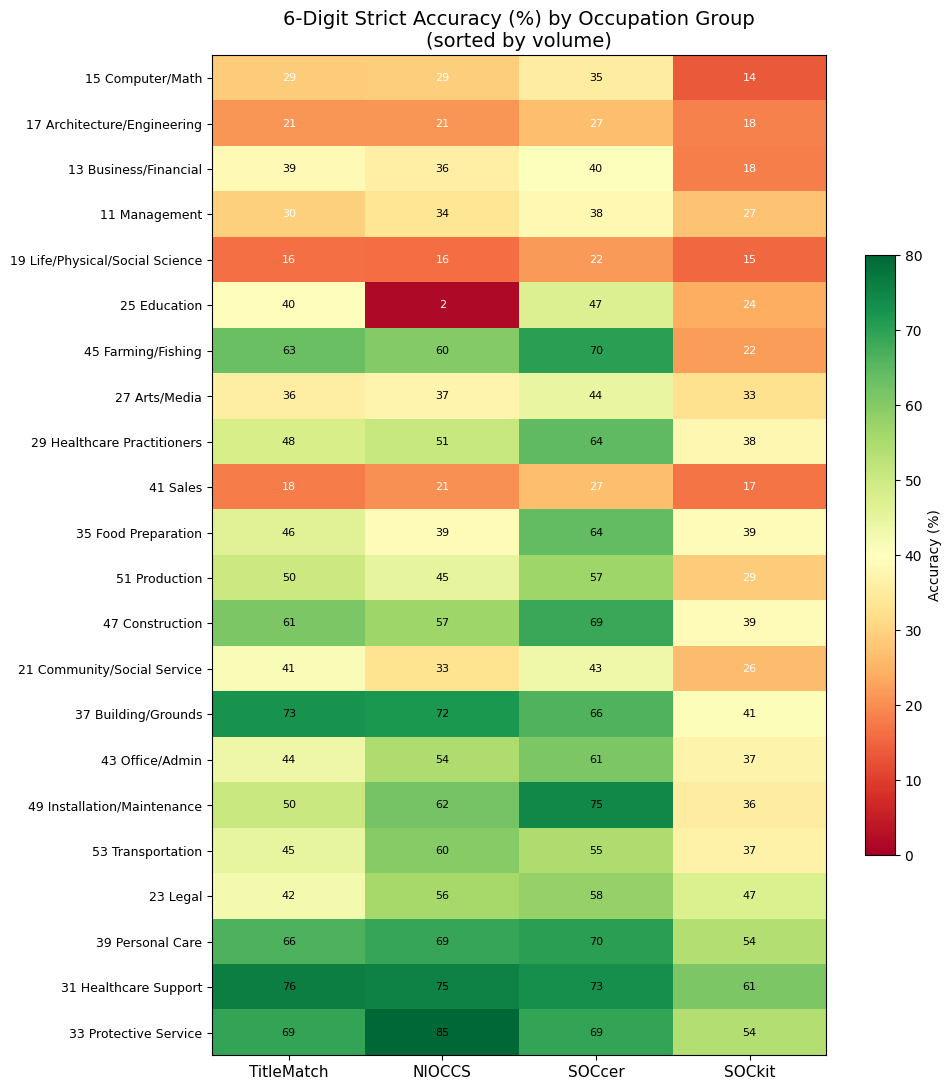

In [17]:
df['soc_2digit'] = df['lca_code'].apply(
    lambda x: str(int(x)).zfill(6)[:2] if pd.notna(x) else None)

soc_labels = {
    '11': 'Management', '13': 'Business/Financial', '15': 'Computer/Math',
    '17': 'Architecture/Engineering', '19': 'Life/Physical/Social Science',
    '21': 'Community/Social Service', '23': 'Legal', '25': 'Education',
    '27': 'Arts/Media', '29': 'Healthcare Practitioners', '31': 'Healthcare Support',
    '33': 'Protective Service', '35': 'Food Preparation', '37': 'Building/Grounds',
    '39': 'Personal Care', '41': 'Sales', '43': 'Office/Admin',
    '45': 'Farming/Fishing', '47': 'Construction', '49': 'Installation/Maintenance',
    '51': 'Production', '53': 'Transportation',
}

heatmap_data = {}
for tool_label in active_tools:
    tool_prefix = TOOLS[tool_label]
    col = f'{tool_prefix}_match_6_digit'
    if col not in df.columns or df[col].isna().all():
        continue
    valid = df[df[col].notna() & df['soc_2digit'].notna()].copy()
    valid[col] = valid[col].astype(float)
    rates = valid.groupby('soc_2digit')[col].mean() * 100
    heatmap_data[tool_label] = rates

heatmap_df = pd.DataFrame(heatmap_data).astype(float)

# Sort by total volume (most common SOC groups at top)
group_counts = df[df['soc_2digit'].notna()].groupby('soc_2digit').size()
heatmap_df = heatmap_df.loc[group_counts.reindex(heatmap_df.index).sort_values(ascending=False).index]

heatmap_df.index = [f'{code} {soc_labels.get(code, "")}' for code in heatmap_df.index]
heatmap_df = heatmap_df.dropna(how='all')

# Reorder columns to match other figures
col_order = ['TitleMatch', 'NIOCCS', 'SOCcer', 'SOCkit']
col_order = [c for c in col_order if c in heatmap_df.columns]
heatmap_df = heatmap_df[col_order]

fig, ax = plt.subplots(figsize=(10, max(8, len(heatmap_df) * 0.5)))
im = ax.imshow(heatmap_df.values.astype(float), cmap='RdYlGn', aspect='auto', vmin=0, vmax=80)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, fontsize=11)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=9)

for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        val = heatmap_df.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8,
                    color='white' if val < 30 else 'black')

ax.set_title('6-Digit Strict Accuracy (%) by Occupation Group\n(sorted by volume)', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.6, label='Accuracy (%)')
plt.tight_layout()
plt.show()

## The Title-Only Ceiling

How accurate could any tool be using only job titles? If a perfect oracle always returned the most common SOC code for each title, it would still only match the specific code on a given row 69% of the time — because many rows carry non-modal codes for ambiguous titles. This ceiling is a property of the data, not of any tool.

The figure below shows each tool's 6-digit strict accuracy as a fraction of this theoretical ceiling, by ambiguity level. For unambiguous titles (1 code), the ceiling is near 100% and tools achieve 27-49% of it. For highly ambiguous titles, the ceiling itself drops to single digits.

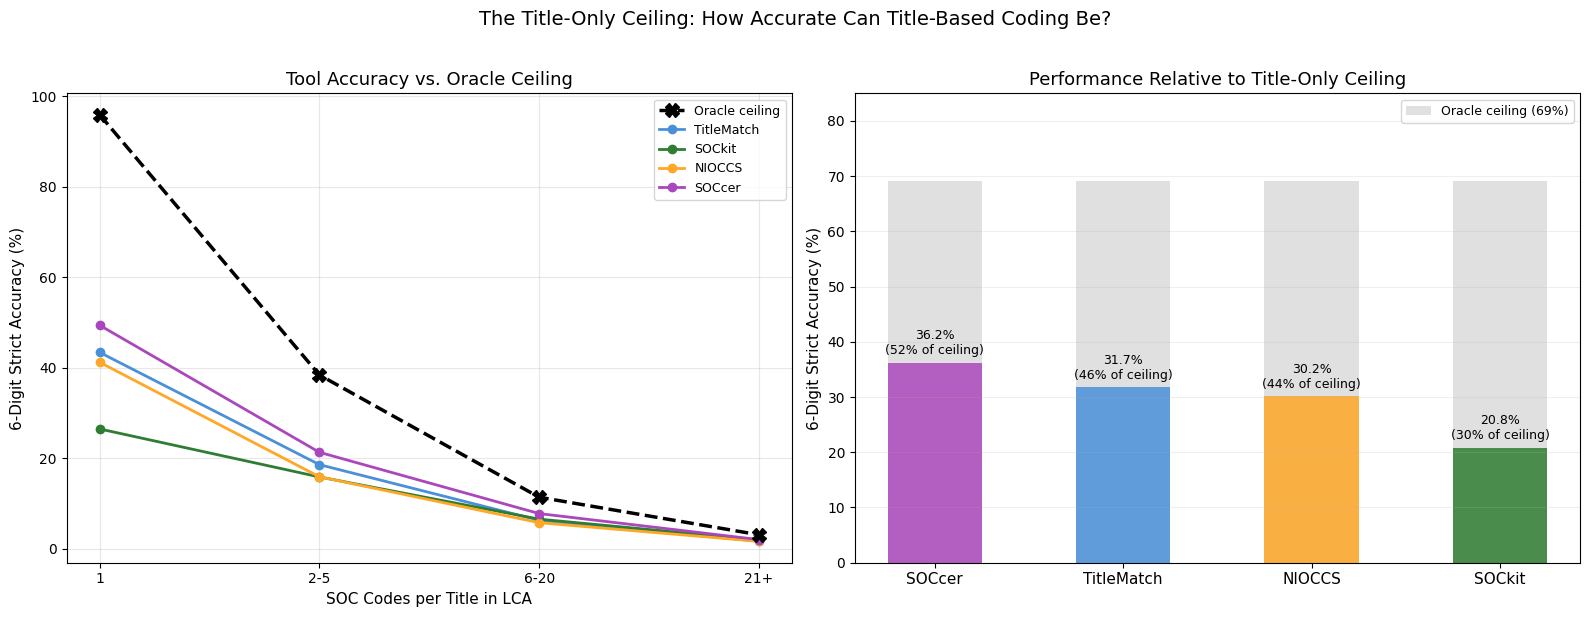

Oracle ceiling (overall): 69.2%
  SOCcer      : 36.2% strict = 52% of ceiling
  TitleMatch  : 31.7% strict = 46% of ceiling
  NIOCCS      : 30.2% strict = 44% of ceiling
  SOCkit      : 20.8% strict = 30% of ceiling


In [18]:
# Compute oracle ceiling per ambiguity bin
modal = (df[df['lca_code'].notna()]
         .sort_values(['job_title', 'count', 'lca_code'], ascending=[True, False, True])
         .groupby('job_title')['lca_code'].first().to_dict())
df['_is_modal'] = df['lca_code'] == df['job_title'].map(modal)

bins = [0, 1, 5, 20, 10000]
bin_labels = ['1', '2-5', '6-20', '21+']
df['ambiguity_bin'] = pd.cut(df['unique_occs_per_title'], bins=bins, labels=bin_labels)

ceiling_by_bin = df.groupby('ambiguity_bin', observed=True)['_is_modal'].mean() * 100
ceiling_overall = df['_is_modal'].mean() * 100

# Figure 1: Tool accuracy vs oracle ceiling by ambiguity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: absolute accuracy + ceiling
ax = axes[0]
ax.plot(bin_labels, ceiling_by_bin.values, marker='X', color='black',
        linewidth=2.5, markersize=10, label='Oracle ceiling', linestyle='--', zorder=5)
for tool_label in active_tools:
    tool_prefix = TOOLS[tool_label]
    col = f'{tool_prefix}_match_6_digit'
    if col not in df.columns or df[col].isna().all():
        continue
    valid = df[df[col].notna()].copy()
    valid[col] = valid[col].astype(float)
    rates = valid.groupby('ambiguity_bin', observed=True)[col].mean() * 100
    ax.plot(rates.index, rates.values, marker='o', label=tool_label,
            color=TOOL_COLORS[tool_label], linewidth=2)
ax.set_xlabel('SOC Codes per Title in LCA', fontsize=11)
ax.set_ylabel('6-Digit Strict Accuracy (%)', fontsize=11)
ax.set_title('Tool Accuracy vs. Oracle Ceiling', fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right panel: summary bar chart — overall performance as % of ceiling
ax2 = axes[1]
tool_data = []
for tool_label in active_tools:
    tool_prefix = TOOLS[tool_label]
    col = f'{tool_prefix}_match_6_digit'
    if col not in df.columns or df[col].isna().all():
        continue
    valid = df[df[col].notna()]
    strict = valid[col].astype(float).mean() * 100
    pct_of_ceiling = strict / ceiling_overall * 100
    tool_data.append((tool_label, strict, pct_of_ceiling))

tool_data.sort(key=lambda x: -x[1])
names = [d[0] for d in tool_data]
strict_vals = [d[1] for d in tool_data]
pct_vals = [d[2] for d in tool_data]

x = np.arange(len(names))
bars_ceil = ax2.bar(x, [ceiling_overall]*len(names), 0.5, color='#E0E0E0',
                     label=f'Oracle ceiling ({ceiling_overall:.0f}%)')
bars_tool = ax2.bar(x, strict_vals, 0.5,
                     color=[TOOL_COLORS[n] for n in names], alpha=0.85)

for i, (name, strict, pct) in enumerate(tool_data):
    ax2.text(i, strict + 1, f'{strict:.1f}%\n({pct:.0f}% of ceiling)',
             ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(names, fontsize=11)
ax2.set_ylabel('6-Digit Strict Accuracy (%)', fontsize=11)
ax2.set_title('Performance Relative to Title-Only Ceiling', fontsize=13)
ax2.set_ylim(0, 85)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(axis='y', alpha=0.2)

fig.suptitle('The Title-Only Ceiling: How Accurate Can Title-Based Coding Be?',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Oracle ceiling (overall): {ceiling_overall:.1f}%')
for name, strict, pct in tool_data:
    print(f'  {name:12s}: {strict:.1f}% strict = {pct:.0f}% of ceiling')

df = df.drop(columns=['_is_modal'])

## Discussion

### Results

At 6-digit strict accuracy, SOCcer leads (36.2%), followed by TitleMatch (31.7%), NIOCCS (30.2%), and SOCkit (20.8%). SOCcer's advantage increases under the any-match frame (48.3% vs 42.9% for TitleMatch). At 2-digit, NIOCCS leads (65.1%) followed by SOCcer (63.5%) and TitleMatch (61.6%).

Weighting by filing count changes the picture: TitleMatch and NIOCCS gain 16-17 percentage points, compared to 9-10pp for SOCcer and SOCkit. On high-frequency filings — standardized titles like "Software Developer" or "Accountant" — TitleMatch and NIOCCS perform substantially better than their unweighted rates suggest.

Tool rankings shift by granularity and evaluation frame. No single tool dominates across all conditions.

### The ground truth ceiling

An oracle that always returns the modal SOC code for each title — the best possible single-code prediction — achieves only 69% strict accuracy on this data. For titles with 2-5 attested codes, the ceiling is 38%; for titles with 6-20 codes, 11%. This means that much of the apparent "error" in occupational coding tools reflects inherent ambiguity in the title-to-occupation mapping, not tool failure.

Against this 69% ceiling, SOCcer's 36.2% represents 52% of theoretically achievable accuracy, and TitleMatch's 31.7% represents 46%. The remaining gap — between tool performance and the ceiling — reflects cases where the tool returns a non-modal but potentially valid code, or genuinely misclassifies.

### The ground truth problem

A single tool's reported accuracy ranges by 10-16 percentage points depending on the evaluation frame. 85% of titles in the deduplicated data map to a single SOC code; for these, ground truth is unambiguous. The remaining 15% — often high-volume, generic titles — map to multiple codes, and strict accuracy for these titles drops below 5% for all tools.

Pairwise agreement between tools is low (28-32% at 6-digit), indicating that tools make different errors. This suggests potential complementarity: ensemble or majority-vote approaches may outperform any individual tool.

### Methodological implications

Benchmarks of occupational coding tools should report accuracy under multiple evaluation frames and specify whether results are weighted by frequency. SOC version differences between tools and ground truth must be addressed via crosswalk — the SOC 2010-to-2018 crosswalk improved SOCcer's 6-digit strict accuracy by 7.2 percentage points.

The results indicate that job titles alone are insufficient for reliable 6-digit occupational classification. Even the best-performing tool achieves only 36% strict accuracy at the detailed occupation level, and the theoretical ceiling from titles alone is 69%. Improving occupational coding will require additional inputs beyond the title — such as task descriptions, industry context, wage level, or employer characteristics — as well as continued development of hybrid approaches that combine automated tools with expert review.

### Benchmark characteristics

**Strengths:** 65,645 title-code pairs across 47,180 unique titles, employer-assigned codes, multi-year (2008-2024), five visa types.

**Limitations:** H-1B titles comprise 82% of filings. Titles are uncleaned. SOC codes in LCA filings may reflect employer errors or strategic choices rather than true occupational classification. SOCcer uses SOC 2010 (crosswalked to 2018 via BLS crosswalk; 42 codes have 1-to-many mappings scored as any-match).

### Tools

- **TitleMatch:** [github.com/Job-Ad-Research-at-QSB-LUC/JAAT](https://github.com/Job-Ad-Research-at-QSB-LUC/JAAT)
- **SOCkit:** [github.com/ripl-org/sockit](https://github.com/ripl-org/sockit)
- **NIOCCS:** [csams.cdc.gov/nioccs](https://csams.cdc.gov/nioccs/)
- **SOCcer/SOCcerNET:** [soccer.nci.nih.gov](https://soccer.nci.nih.gov/)
- **Analysis:** `build_comparison.py`, `run_nioccs.py`